In [212]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score


In [213]:
import os
import pandas as pd

file_path = "../data/dados_bitcoin_gdelt_limpos.csv"
file_path2 = "../data/dados_bitcoin_gdelt_limpos_2.csv" if os.path.exists("../data/dados_bitcoin_gdelt_limpos_2.csv") else "../data/dados_bitcoin_gdelt_limpos2.csv"

df1 = pd.read_csv(file_path)

if os.path.exists(file_path2):
    df2 = pd.read_csv(file_path2)
    df = pd.concat([df1, df2], axis=0).drop_duplicates(subset=["URL"]).reset_index(drop=True)
    print(f"Datasets combinados: {len(df1)} + {len(df2)} -> {len(df)} notícias únicas.")
else:
    df = df1
    print(f"Dataset carregado: {len(df)} notícias.")

display(df.head())


Datasets combinados: 48649 + 30554 -> 79186 notícias únicas.


,EventTimestamp,Source,URL,SentimentScore,Temas,Organizacoes
0,2020-07-21 17:15:00+00:00,reuters.com,https://af.reuters.com/article/worldNews/idAFK...,-5.590062,"WB_678_DIGITAL_GOVERNMENT,2652;WB_670_ICT_SECU...","Chinese Embassy,552;National Security John Dem..."
1,2021-05-19 04:30:00+00:00,reuters.com,https://cn.reuters.com/article/china-virtual-c...,-2.649007,"WB_2048_COMPENSATION_CAREERS_AND_INCENTIVES,79...",Association China Banking The Association Chin...
2,2020-12-18 09:45:00+00:00,reuters.com,https://cn.reuters.com/article/global-markets-...,1.504788,"CRISISLEX_CRISISLEXREC,976;EPU_POLICY_CONGRESS...","Swiss National Bank,3111;Federal Reserve,454;F..."
3,2021-05-13 07:30:00+00:00,reuters.com,https://cn.reuters.com/article/huobi-0513-thur...,0.743494,"WB_336_NON_BANK_FINANCIAL_INSTITUTIONS,1231;WB...","Group Operations,725"
4,2021-08-07 10:45:00+00:00,cointelegraph.com,https://cointelegraph.com/authors/laurent-descout,-4.347826,"ECON_BITCOIN,71;",NaN


In [214]:
# 1. Extração de tags de temas e organizações como identificadores atômicos
def extrair_entidades(raw_str):
    if pd.isna(raw_str):
        return []
    return list(set([item.split(",")[0].strip() for item in str(raw_str).replace(",", ";").split(";") if item.strip() and not item.strip().isdigit()]))

temas_series = df["Temas"].apply(extrair_entidades)
orgs_series = df["Organizacoes"].apply(extrair_entidades)

# 2. Contagem e filtro da stop-word de domínio: 'ECON_BITCOIN'
# Como a base foi coletada buscando por 'bitcoin', ECON_BITCOIN aparece em 99.64%
# dos artigos (IDF ~ 0). Mantê-lo criaria um cluster artificial sem poder de separação.
tema_counts = temas_series.explode().value_counts()
temas_validos = tema_counts[tema_counts.index != "ECON_BITCOIN"]
org_counts = orgs_series.explode().value_counts()

# Seleção das Top 80 tags de temas válidos e Top 50 organizações
top_80_temas = ["TAG_" + t for t in temas_validos.head(80).index]
top_50_orgs = ["ORG_" + o for o in org_counts.head(50).index]

print(f"Total de temas válidos selecionados (sem ECON_BITCOIN): {len(top_80_temas)}")
print(f"Total de organizações selecionadas: {len(top_50_orgs)}")

# Espaço Unificado: 130 conceitos (80 Temas + 50 Organizações)
todas_features = top_80_temas + top_50_orgs
feat_to_idx = {f: i for i, f in enumerate(todas_features)}


Total de temas válidos selecionados (sem ECON_BITCOIN): 80
Total de organizações selecionadas: 50


In [215]:
# 2. Justificativa Metodológica da Seleção (80 Temas / 50 Organizações) via Pareto & Zipf
total_tags_unicas = len(tema_counts)
total_orgs_unicas = len(org_counts)
mencoes_validas_temas = temas_validos.sum()
mencoes_top80_temas = temas_validos.head(80).sum()
mencoes_total_orgs = org_counts.sum()
mencoes_top50_orgs = org_counts.head(50).sum()

top_80_set = set(temas_validos.head(80).index)
top_50_set = set(org_counts.head(50).index)
cobertura_docs = sum(
    any(t in top_80_set for t in t_list) or any(o in top_50_set for o in o_list)
    for t_list, o_list in zip(temas_series, orgs_series)
)

print("=" * 80)
print("JUSTIFICATIVA METODOLÓGICA: SELEÇÃO 80 TEMAS / 50 ORGANIZAÇÕES (LEI DE ZIPF & PARETO)")
print("=" * 80)
print(f"1. Remoção de Stop-word de Domínio: 'ECON_BITCOIN' aparecia em {tema_counts.get('ECON_BITCOIN', 0):,} notícias ({tema_counts.get('ECON_BITCOIN', 0)/len(df)*100:.2f}% do total).")
print("   Sua exclusão elimina o cluster redundante de variância nula e viés de coleta.")
print(f"\n2. Concentração de Temas (Top 80 de {total_tags_unicas:,} tags únicas):")
print(f"   • Representam {mencoes_top80_temas:,} de {mencoes_validas_temas:,} menções válidas ({mencoes_top80_temas/mencoes_validas_temas*100:.2f}% do volume total).")
print(f"\n3. Concentração de Organizações (Top 50 de {total_orgs_unicas:,} orgs únicas):")
print(f"   • Representam {mencoes_top50_orgs:,} de {mencoes_total_orgs:,} menções ({mencoes_top50_orgs/mencoes_total_orgs*100:.2f}% do volume total).")
print(f"\n4. Cobertura Documental Total:")
print(f"   • {cobertura_docs:,} de {len(df):,} notícias ({cobertura_docs/len(df)*100:.2f}%) contêm ao menos uma das 130 features selecionadas.")
print("   • Equilíbrio ótimo entre dimensionalidade controlada (130 variáveis) e cobertura informativa (>98%).")
print("=" * 80)


JUSTIFICATIVA METODOLÓGICA: SELEÇÃO 80 TEMAS / 50 ORGANIZAÇÕES (LEI DE ZIPF & PARETO)
1. Remoção de Stop-word de Domínio: 'ECON_BITCOIN' aparecia em 78,904 notícias (99.64% do total).
   Sua exclusão elimina o cluster redundante de variância nula e viés de coleta.

2. Concentração de Temas (Top 80 de 4,844 tags únicas):
   • Representam 996,390 de 1,976,870 menções válidas (50.40% do volume total).

3. Concentração de Organizações (Top 50 de 25,004 orgs únicas):
   • Representam 103,341 de 211,897 menções (48.77% do volume total).

4. Cobertura Documental Total:
   • 78,063 de 79,186 notícias (98.58%) contêm ao menos uma das 130 features selecionadas.
   • Equilíbrio ótimo entre dimensionalidade controlada (130 variáveis) e cobertura informativa (>98%).


In [216]:
# 3. Construção da Matriz Binária Notícia x Conceito (48.649 notícias x 130 variáveis)
X = np.zeros((len(df), len(todas_features)), dtype=bool)

for i, (t_list, o_list) in enumerate(zip(temas_series, orgs_series)):
    for t in t_list:
        k = "TAG_" + t
        if k in feat_to_idx:
            X[i, feat_to_idx[k]] = True
    for o in o_list:
        k = "ORG_" + o
        if k in feat_to_idx:
            X[i, feat_to_idx[k]] = True

# Normalização L2 para agrupamento baseado em coocorrência angular (cosseno / Ward)
X_norm = normalize(X.astype(int).T)
print(f"Matriz de representação das variáveis: {X_norm.shape} (130 variáveis x {len(df)} notícias)")


Matriz de representação das variáveis: (130, 79186) (130 variáveis x 79186 notícias)


In [217]:
# 4. Determinação do K ótimo via Silhouette Score (Zero Arbitrariedade)
melhor_k, melhor_score = 0, -1
scores = {}

for k in range(2, 11):
    model = AgglomerativeClustering(n_clusters=k, metric="euclidean", linkage="ward")
    labels = model.fit_predict(X_norm)
    score = silhouette_score(X_norm, labels)
    scores[k] = score
    if score > melhor_score:
        melhor_score = score
        melhor_k = k
    print(f"k = {k:2d} -> Silhouette Score: {score:.4f}")

print(f"\n=> Número ótimo de clusters selecionado matematicamente: k = {melhor_k} (Score: {melhor_score:.4f})")


k =  2 -> Silhouette Score: 0.0313
k =  3 -> Silhouette Score: 0.0344
k =  4 -> Silhouette Score: 0.0227
k =  5 -> Silhouette Score: 0.0390
k =  6 -> Silhouette Score: 0.0480
k =  7 -> Silhouette Score: 0.0501
k =  8 -> Silhouette Score: 0.0567
k =  9 -> Silhouette Score: 0.0591
k = 10 -> Silhouette Score: 0.0684

=> Número ótimo de clusters selecionado matematicamente: k = 10 (Score: 0.0684)


In [218]:
# 5. Ajuste do Modelo Final e Extração dos Clusters
final_model = AgglomerativeClustering(n_clusters=melhor_k, metric="euclidean", linkage="ward")
cluster_labels = final_model.fit_predict(X_norm)

clusters_dict = {}
for feat, cid in zip(todas_features, cluster_labels):
    clusters_dict.setdefault(cid, []).append(feat)

print("=" * 65)
print(f"RESULTADO DA CLUSTERIZAÇÃO UNIFICADA ({melhor_k} MACRO-CLUSTERS)")
print("=" * 65)

for cid, itens in sorted(clusters_dict.items()):
    tags = [i.replace("TAG_", "") for i in itens if i.startswith("TAG_")]
    orgs = [i.replace("ORG_", "") for i in itens if i.startswith("ORG_")]
    print(f"\n--- CLUSTER {cid + 1} ({len(itens)} itens: {len(tags)} temas, {len(orgs)} orgs) ---")
    if tags:
        print(f"  • Temas ({len(tags)}): {", ".join(tags[:6])}{"..." if len(tags) > 6 else ""}")
    if orgs:
        print(f"  • Organizações ({len(orgs)}): {", ".join(orgs[:5])}{"..." if len(orgs) > 5 else ""}")


RESULTADO DA CLUSTERIZAÇÃO UNIFICADA (10 MACRO-CLUSTERS)

--- CLUSTER 1 (25 itens: 23 temas, 2 orgs) ---
  • Temas (23): UNGP_FORESTS_RIVERS_OCEANS, CRISISLEX_CRISISLEXREC, WB_133_INFORMATION_AND_COMMUNICATION_TECHNOLOGIES, WB_678_DIGITAL_GOVERNMENT, CRISISLEX_C07_SAFETY, TAX_FNCACT_CEO...
  • Organizações (2): United States, Digital Currency Group

--- CLUSTER 2 (40 itens: 2 temas, 38 orgs) ---
  • Temas (2): MEDIA_SOCIAL, TAX_FNCACT_DIRECTOR
  • Organizações (38): Twitter, Bloomberg, Facebook, Thomson Reuters, European Union...

--- CLUSTER 3 (22 itens: 16 temas, 6 orgs) ---
  • Temas (16): WB_698_TRADE, TAX_ECON_PRICE, ECON_STOCKMARKET, WB_1104_MACROECONOMIC_VULNERABILITY_AND_DEBT, TAX_FNCACT_TRADERS, IDEOLOGY...
  • Organizações (6): Reuters, Thomson Reuters Trust Principles, Federal Reserve, Nasdaq, European Central Bank...

--- CLUSTER 4 (10 itens: 8 temas, 2 orgs) ---
  • Temas (8): EPU_CATS_REGULATION, EPU_POLICY_REGULATORY, LEGISLATION, EPU_CATS_FINANCIAL_REGULATION, TAX_FNCAC

In [219]:
# 6. Engenharia de Features: Adicionar indicadores dos clusters no DataFrame
for cid, itens in sorted(clusters_dict.items()):
    col_count = f"cluster_{cid + 1}_count"
    col_flag = f"cluster_{cid + 1}_flag"
    col_sent = f"cluster_{cid + 1}_sent"
    
    indices_cluster = [feat_to_idx[feat] for feat in itens]
    
    df[col_count] = X[:, indices_cluster].sum(axis=1)
    df[col_flag] = (df[col_count] > 0).astype(int)
    df[col_sent] = np.where(df[col_flag] == 1, df["SentimentScore"], np.nan)

print("Novas colunas de clusters geradas no DataFrame com sucesso!")
display(df.head())


Novas colunas de clusters geradas no DataFrame com sucesso!


,EventTimestamp,Source,URL,SentimentScore,Temas,Organizacoes,cluster_1_count,cluster_1_flag,cluster_1_sent,cluster_2_count,...,cluster_7_sent,cluster_8_count,cluster_8_flag,cluster_8_sent,cluster_9_count,cluster_9_flag,cluster_9_sent,cluster_10_count,cluster_10_flag,cluster_10_sent
0,2020-07-21 17:15:00+00:00,reuters.com,https://af.reuters.com/article/worldNews/idAFK...,-5.590062,"WB_678_DIGITAL_GOVERNMENT,2652;WB_670_ICT_SECU...","Chinese Embassy,552;National Security John Dem...",12,1,-5.590062,0,...,-5.590062,0,0,NaN,2,1,-5.590062,0,0,NaN
1,2021-05-19 04:30:00+00:00,reuters.com,https://cn.reuters.com/article/china-virtual-c...,-2.649007,"WB_2048_COMPENSATION_CAREERS_AND_INCENTIVES,79...",Association China Banking The Association Chin...,2,1,-2.649007,0,...,-2.649007,1,1,-2.649007,3,1,-2.649007,0,0,NaN
2,2020-12-18 09:45:00+00:00,reuters.com,https://cn.reuters.com/article/global-markets-...,1.504788,"CRISISLEX_CRISISLEXREC,976;EPU_POLICY_CONGRESS...","Swiss National Bank,3111;Federal Reserve,454;F...",4,1,1.504788,0,...,1.504788,1,1,1.504788,9,1,1.504788,4,1,1.504788
3,2021-05-13 07:30:00+00:00,reuters.com,https://cn.reuters.com/article/huobi-0513-thur...,0.743494,"WB_336_NON_BANK_FINANCIAL_INSTITUTIONS,1231;WB...","Group Operations,725",2,1,0.743494,0,...,NaN,1,1,0.743494,1,1,0.743494,0,0,NaN
4,2021-08-07 10:45:00+00:00,cointelegraph.com,https://cointelegraph.com/authors/laurent-descout,-4.347826,"ECON_BITCOIN,71;",NaN,0,0,NaN,0,...,NaN,0,0,NaN,0,0,NaN,0,0,NaN


In [220]:
# 7. Informações e estatísticas do DataFrame atualizado
df.info()
print("\nSentimento médio geral do dataset:", df["SentimentScore"].mean())


<class 'pandas.DataFrame'>
RangeIndex: 79186 entries, 0 to 79185
Data columns (total 36 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   EventTimestamp    79186 non-null  str    
 1   Source            79186 non-null  str    
 2   URL               79186 non-null  str    
 3   SentimentScore    79186 non-null  float64
 4   Temas             78991 non-null  str    
 5   Organizacoes      63625 non-null  str    
 6   cluster_1_count   79186 non-null  int64  
 7   cluster_1_flag    79186 non-null  int64  
 8   cluster_1_sent    65772 non-null  float64
 9   cluster_2_count   79186 non-null  int64  
 10  cluster_2_flag    79186 non-null  int64  
 11  cluster_2_sent    36441 non-null  float64
 12  cluster_3_count   79186 non-null  int64  
 13  cluster_3_flag    79186 non-null  int64  
 14  cluster_3_sent    65245 non-null  float64
 15  cluster_4_count   79186 non-null  int64  
 16  cluster_4_flag    79186 non-null  int64  
 17  clus

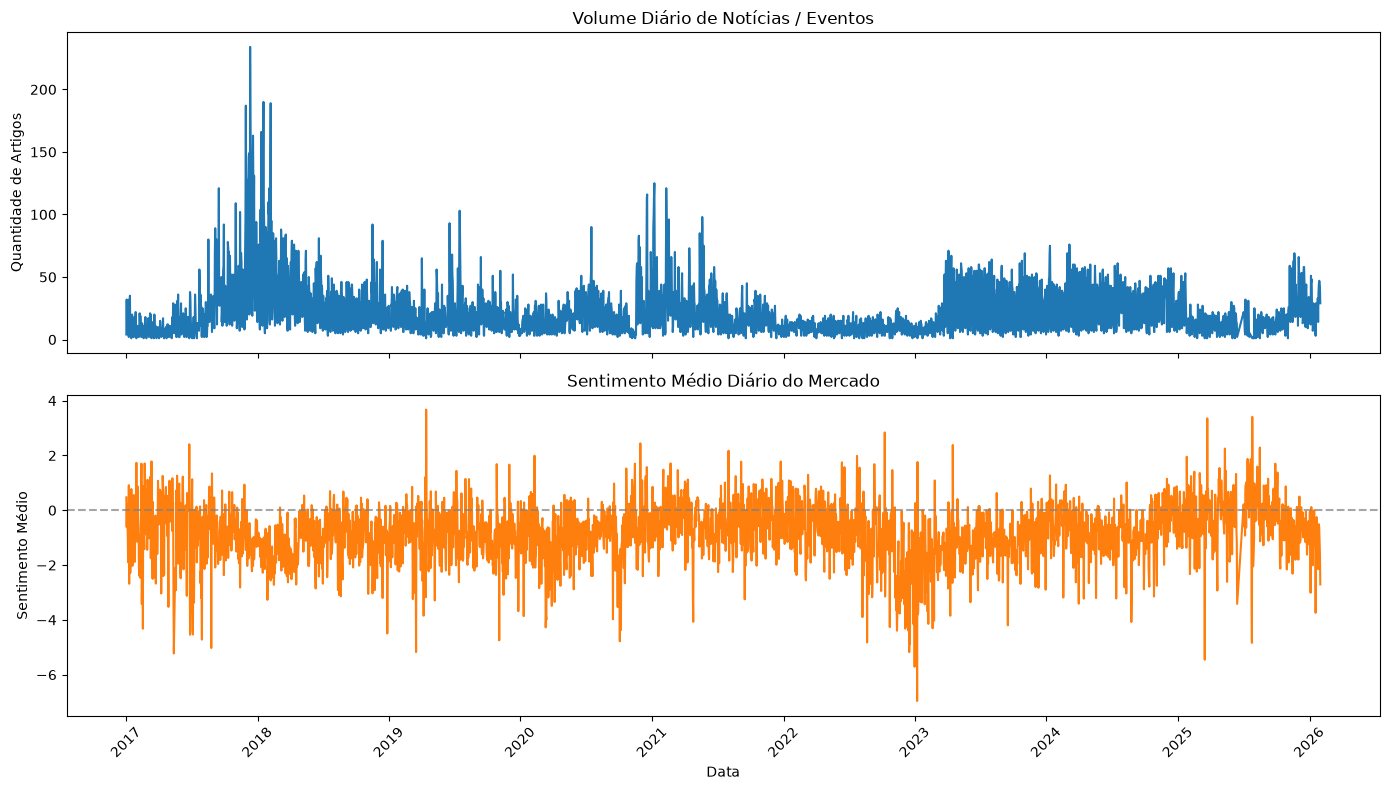

In [221]:
# 8. Análise Temporal Diária (Volume e Sentimento Médio)
df["EventTimestamp"] = pd.to_datetime(df["EventTimestamp"])
df["Date"] = df["EventTimestamp"].dt.date

daily_stats = (
    df.groupby("Date")
    .agg(
        Article_Count=("SentimentScore", "count"),
        Mean_Sentiment=("SentimentScore", "mean"),
    )
    .reset_index()
)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

sns.lineplot(data=daily_stats, x="Date", y="Article_Count", ax=axes[0], color="tab:blue")
axes[0].set_title("Volume Diário de Notícias / Eventos")
axes[0].set_ylabel("Quantidade de Artigos")

sns.lineplot(data=daily_stats, x="Date", y="Mean_Sentiment", ax=axes[1], color="tab:orange")
axes[1].axhline(0, color="gray", linestyle="--", alpha=0.7)
axes[1].set_title("Sentimento Médio Diário do Mercado")
axes[1].set_ylabel("Sentimento Médio")
axes[1].set_xlabel("Data")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [222]:
# 9. Comparativo de Sentimento Médio por Cluster Algorítmico
cluster_sentiments = {}

for cid in sorted(clusters_dict.keys()):
    c_name = f"cluster_{cid + 1}"
    mean_s = df[df[f"{c_name}_flag"] == 1]["SentimentScore"].mean()
    count_s = (df[f"{c_name}_flag"] == 1).sum()
    cluster_sentiments[c_name] = {
        "Sentimento_Medio": round(mean_s, 4),
        "Volume_Noticias": count_s,
        "Itens_no_Cluster": len(clusters_dict[cid])
    }

df_cluster_resumo = pd.DataFrame(cluster_sentiments).T
display(df_cluster_resumo.sort_values(by="Sentimento_Medio", ascending=False))


,Sentimento_Medio,Volume_Noticias,Itens_no_Cluster
cluster_5,-0.4436,836.0,2.0
cluster_10,-0.6276,10474.0,4.0
cluster_2,-0.8025,36441.0,40.0
cluster_9,-0.8842,56144.0,10.0
cluster_6,-0.8906,15403.0,4.0
cluster_3,-0.9014,65245.0,22.0
cluster_1,-0.9636,65772.0,25.0
cluster_4,-1.2164,32557.0,10.0
cluster_8,-1.2537,26696.0,7.0
cluster_7,-1.5412,29568.0,6.0


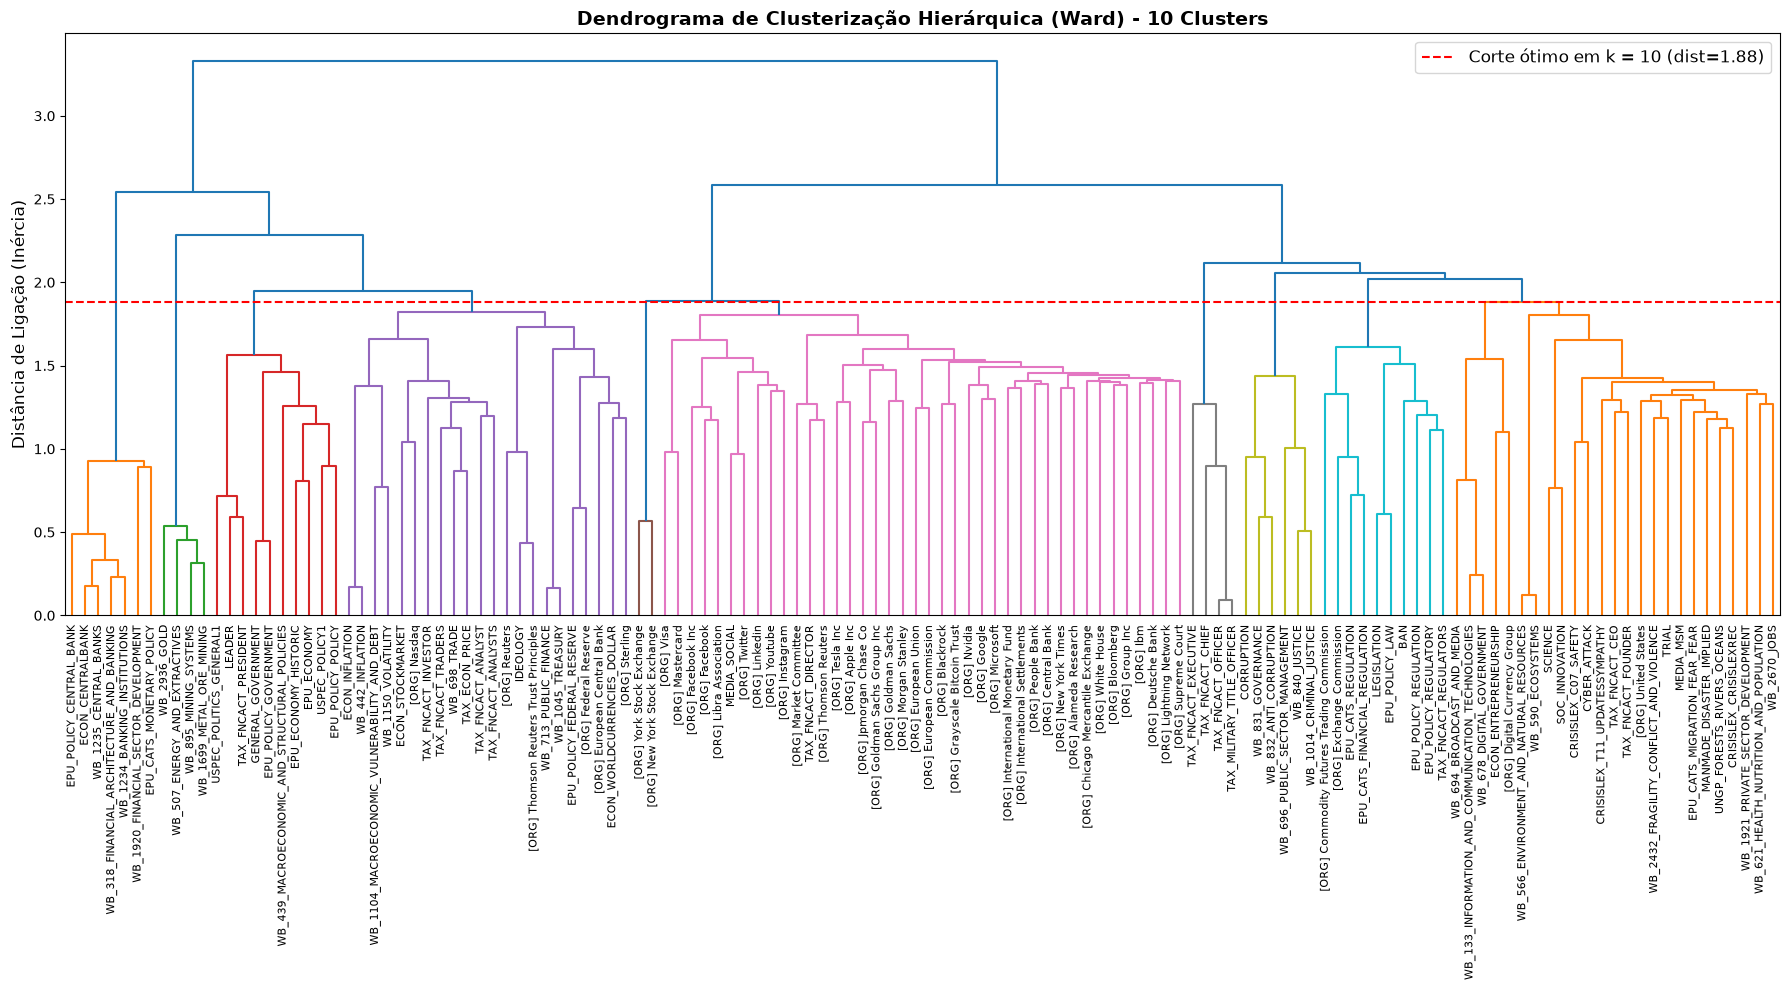

In [223]:
# 10. Visualização 1: Dendrograma Hierárquico dos Clusters
from scipy.cluster.hierarchy import linkage, dendrogram

Z = linkage(X_norm, method="ward")
cut_threshold = (Z[-(melhor_k - 1), 2] + Z[-melhor_k, 2]) / 2.0

plt.figure(figsize=(18, 10))
dendrogram(
    Z,
    labels=[f.replace("TAG_", "").replace("ORG_", "[ORG] ") for f in todas_features],
    color_threshold=cut_threshold,
    leaf_rotation=90,
    leaf_font_size=8
)
plt.axhline(y=cut_threshold, color="red", linestyle="--", linewidth=1.5, label=f"Corte ótimo em k = {melhor_k} (dist={cut_threshold:.2f})")
plt.title(f"Dendrograma de Clusterização Hierárquica (Ward) - {melhor_k} Clusters", fontsize=14, fontweight="bold")
plt.ylabel("Distância de Ligação (Inércia)", fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()


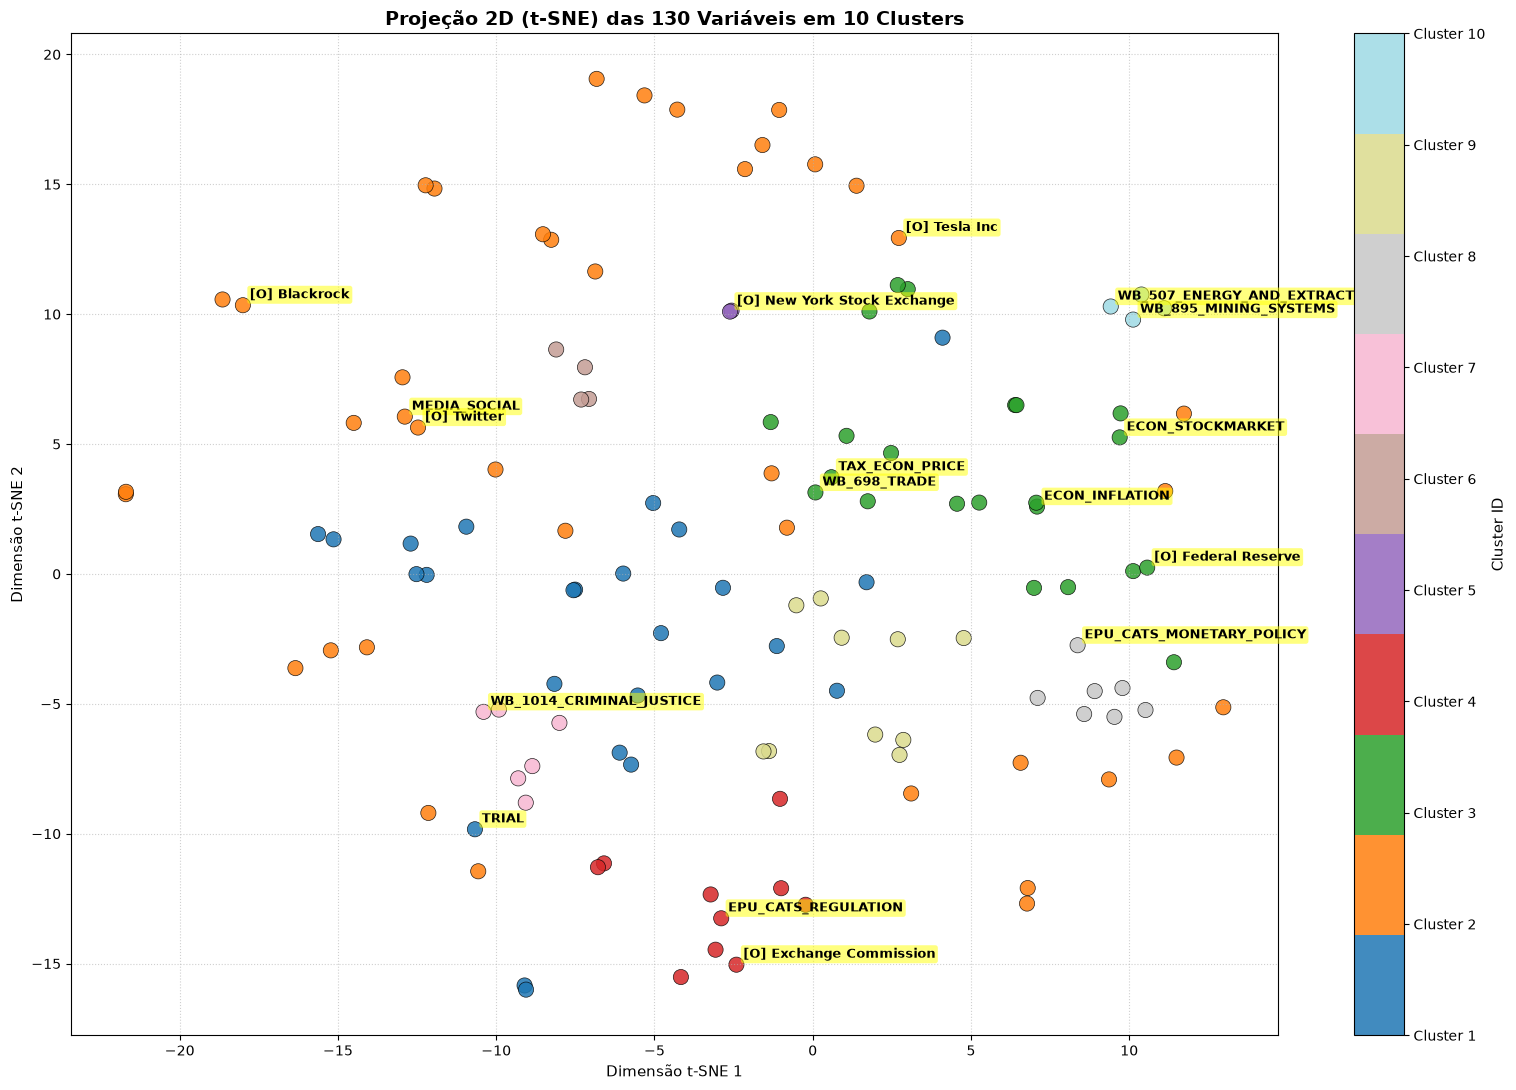

In [224]:
# 11. Visualização 2: Mapa 2D de Projeção Semântica (t-SNE)
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=15, random_state=42, init="random")
coords_2d = tsne.fit_transform(X_norm)

plt.figure(figsize=(16, 11))
cmap = plt.get_cmap("tab20", melhor_k)

scatter = plt.scatter(
    coords_2d[:, 0],
    coords_2d[:, 1],
    c=cluster_labels,
    cmap=cmap,
    s=120,
    alpha=0.85,
    edgecolors="black",
    linewidths=0.5
)

# Anotar apenas as entidades mais expressivas para não poluir
tags_destaque = {
    "TAG_WB_698_TRADE", "TAG_TAX_ECON_PRICE", "TAG_ECON_STOCKMARKET", "ORG_Federal Reserve",
    "TAG_EPU_CATS_MONETARY_POLICY", "TAG_ECON_INFLATION", "ORG_Exchange Commission",
    "TAG_EPU_CATS_REGULATION", "TAG_WB_895_MINING_SYSTEMS", "TAG_WB_507_ENERGY_AND_EXTRACTIVES",
    "ORG_Blackrock", "ORG_Tesla Inc", "ORG_Twitter", "TAG_MEDIA_SOCIAL",
    "TAG_WB_1014_CRIMINAL_JUSTICE", "TAG_TRIAL", "ORG_New York Stock Exchange"
}

for i, feat in enumerate(todas_features):
    label_clean = feat.replace("TAG_", "").replace("ORG_", "[O] ")
    if feat in tags_destaque: # destaques pontuais
        plt.annotate(
            label_clean,
            (coords_2d[i, 0], coords_2d[i, 1]),
            fontsize=9,
            fontweight="bold",
            xytext=(5, 5),
            textcoords="offset points",
            bbox=dict(boxstyle="round,pad=0.2", fc="yellow", alpha=0.5, edgecolor="none")
        )

cbar = plt.colorbar(scatter, ticks=range(melhor_k))
cbar.set_label("Cluster ID", fontsize=11)
cbar.set_ticklabels([f"Cluster {i+1}" for i in range(melhor_k)])

plt.title(f"Projeção 2D (t-SNE) das 130 Variáveis em {melhor_k} Clusters", fontsize=14, fontweight="bold")
plt.xlabel("Dimensão t-SNE 1", fontsize=11)
plt.ylabel("Dimensão t-SNE 2", fontsize=11)
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()


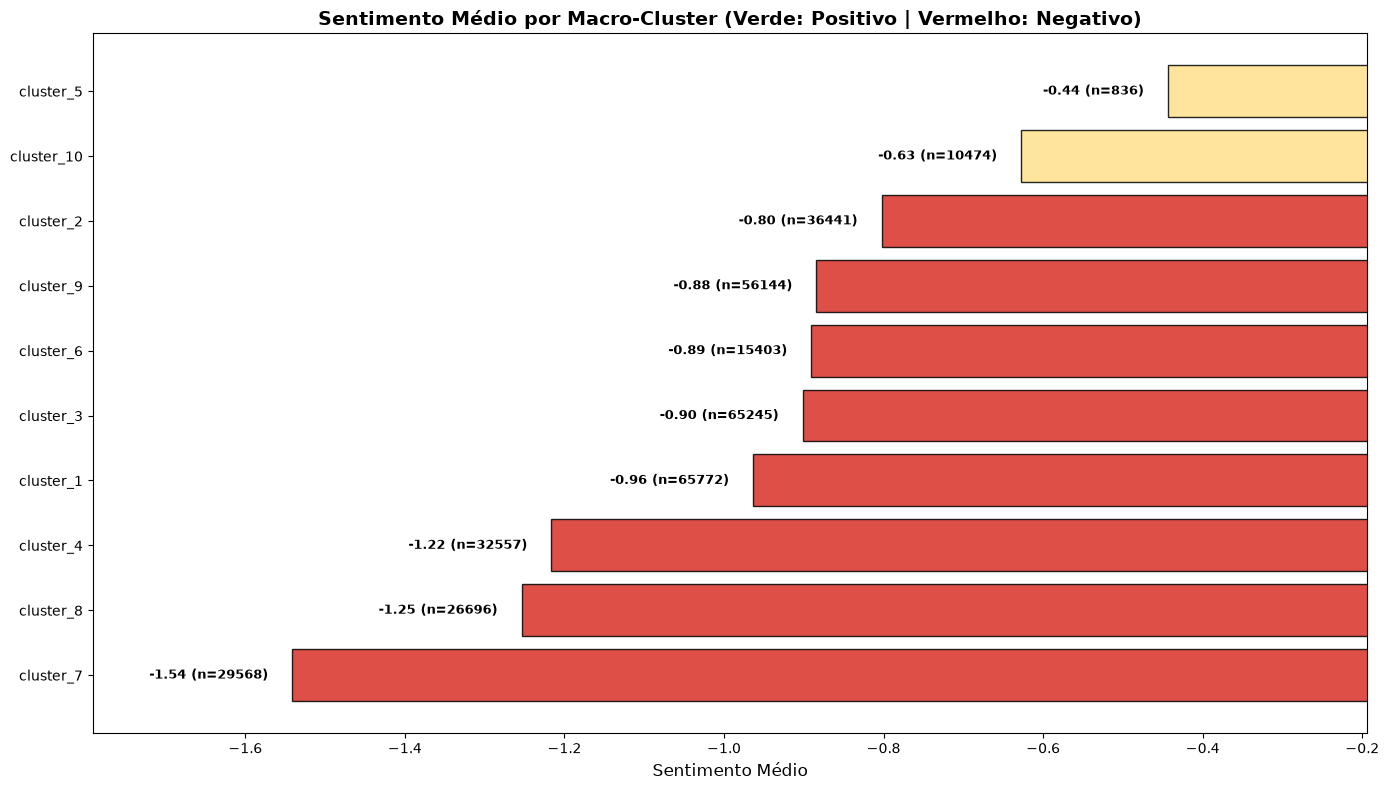

In [225]:
# 12. Visualização 3: Perfil Financeiro dos Clusters (Sentimento x Volume)
df_plot = df_cluster_resumo.copy()
df_plot["Cluster"] = df_plot.index
df_plot = df_plot.sort_values(by="Sentimento_Medio")

cores = ["#d73027" if s < -0.7 else "#fee08b" if s < 0 else "#1a9850" for s in df_plot["Sentimento_Medio"]]

fig, ax1 = plt.subplots(figsize=(14, 8))

y_pos = range(len(df_plot))
bars = ax1.barh(y_pos, df_plot["Sentimento_Medio"], color=cores, edgecolor="black", alpha=0.85)

ax1.set_yticks(y_pos)
ax1.set_yticklabels(df_plot["Cluster"], fontsize=10)
ax1.axvline(0, color="black", linestyle="--", linewidth=1)
ax1.set_xlabel("Sentimento Médio", fontsize=12)
ax1.set_title(f"Sentimento Médio por Macro-Cluster (Verde: Positivo | Vermelho: Negativo)", fontsize=14, fontweight="bold")

# Anotação dos valores nas barras
for idx, bar in enumerate(bars):
    val = df_plot["Sentimento_Medio"].iloc[idx]
    vol = int(df_plot["Volume_Noticias"].iloc[idx])
    offset = 0.03 if val >= 0 else -0.03
    ha = "left" if val >= 0 else "right"
    ax1.text(val + offset, idx, f"{val:.2f} (n={vol})", va="center", ha=ha, fontsize=9, fontweight="bold")

ax1.set_xlim(min(df_plot["Sentimento_Medio"]) - 0.25, max(df_plot["Sentimento_Medio"]) + 0.25)
plt.tight_layout()
plt.show()


In [226]:
# ==============================================================================
# 14. TEMAS E ORGANIZAÇÕES MAIS FREQUENTES EM CADA CLUSTER
# ==============================================================================
dados_resumo_clusters = []

print("=" * 85)
print("RANKING DETALHADO: TEMAS E ORGANIZAÇÕES MAIS FREQUENTES POR CLUSTER")
print("=" * 85)

for cid, itens in sorted(clusters_dict.items()):
    cluster_num = cid + 1
    col_flag = f"cluster_{cluster_num}_flag"
    total_noticias_cluster = int((df[col_flag] == 1).sum())
    
    tags_no_cluster = [feat.replace("TAG_", "") for feat in itens if feat.startswith("TAG_")]
    orgs_no_cluster = [feat.replace("ORG_", "") for feat in itens if feat.startswith("ORG_")]
    
    # Ordenar os temas do cluster por frequência real de menções no dataset
    top_temas_cluster = (
        temas_validos.loc[temas_validos.index.intersection(tags_no_cluster)]
        .sort_values(ascending=False)
    )
    
    # Ordenar as organizações do cluster por frequência real de menções no dataset
    top_orgs_cluster = (
        org_counts.loc[org_counts.index.intersection(orgs_no_cluster)]
        .sort_values(ascending=False)
    )
    
    print(f"\n================================================================================")
    print(f"📁 CLUSTER {cluster_num:2d} | Volume: {total_noticias_cluster:,} notícias ({total_noticias_cluster/len(df)*100:.1f}% do total)")
    print(f"   Composição: {len(itens)} itens ({len(tags_no_cluster)} Temas, {len(orgs_no_cluster)} Organizações)")
    print(f"--------------------------------------------------------------------------------")
    
    print("   📌 Principais Temas do Cluster:")
    if not top_temas_cluster.empty:
        for rank, (tag, count) in enumerate(top_temas_cluster.head(5).items(), 1):
            pct = (count / total_noticias_cluster) * 100
            print(f"      {rank}. {tag:<45} -> {count:,} menções ({pct:.1f}% das notícias do cluster)")
    else:
        print("      (Nenhum tema mapeado neste cluster)")
        
    print("   🏛️  Principais Organizações do Cluster:")
    if not top_orgs_cluster.empty:
        for rank, (org, count) in enumerate(top_orgs_cluster.head(5).items(), 1):
            pct = (count / total_noticias_cluster) * 100
            print(f"      {rank}. {org:<45} -> {count:,} menções ({pct:.1f}% das notícias do cluster)")
    else:
        print("      (Nenhuma organização mapeada neste cluster)")
    
    # Coleta de dados para a tabela resumo consolidada
    dados_resumo_clusters.append({
        "Cluster": f"Cluster {cluster_num}",
        "Volume_Noticias": total_noticias_cluster,
        "Qtd_Temas": len(tags_no_cluster),
        "Top_1_Tema": f"{top_temas_cluster.index[0]} ({top_temas_cluster.iloc[0]:,})" if not top_temas_cluster.empty else "-",
        "Top_2_Tema": f"{top_temas_cluster.index[1]} ({top_temas_cluster.iloc[1]:,})" if len(top_temas_cluster) > 1 else "-",
        "Qtd_Orgs": len(orgs_no_cluster),
        "Top_1_Org": f"{top_orgs_cluster.index[0]} ({top_orgs_cluster.iloc[0]:,})" if not top_orgs_cluster.empty else "-",
        "Top_2_Org": f"{top_orgs_cluster.index[1]} ({top_orgs_cluster.iloc[1]:,})" if len(top_orgs_cluster) > 1 else "-"
    })

# Exibir tabela resumo consolidada
print("\n" + "=" * 85)
print("TABELA RESUMO CONSOLIDADA")
print("=" * 85)
df_tabela_clusters = pd.DataFrame(dados_resumo_clusters)
display(df_tabela_clusters)


RANKING DETALHADO: TEMAS E ORGANIZAÇÕES MAIS FREQUENTES POR CLUSTER

📁 CLUSTER  1 | Volume: 65,772 notícias (83.1% do total)
   Composição: 25 itens (23 Temas, 2 Organizações)
--------------------------------------------------------------------------------
   📌 Principais Temas do Cluster:
      1. UNGP_FORESTS_RIVERS_OCEANS                    -> 23,714 menções (36.1% das notícias do cluster)
      2. CRISISLEX_CRISISLEXREC                        -> 21,566 menções (32.8% das notícias do cluster)
      3. WB_133_INFORMATION_AND_COMMUNICATION_TECHNOLOGIES -> 21,503 menções (32.7% das notícias do cluster)
      4. WB_678_DIGITAL_GOVERNMENT                     -> 20,252 menções (30.8% das notícias do cluster)
      5. CRISISLEX_C07_SAFETY                          -> 14,336 menções (21.8% das notícias do cluster)
   🏛️  Principais Organizações do Cluster:
      1. United States                                 -> 10,610 menções (16.1% das notícias do cluster)
      2. Digital Currency Group 

,Cluster,Volume_Noticias,Qtd_Temas,Top_1_Tema,Top_2_Tema,Qtd_Orgs,Top_1_Org,Top_2_Org
0,Cluster 1,65772,23,"UNGP_FORESTS_RIVERS_OCEANS (23,714)","CRISISLEX_CRISISLEXREC (21,566)",2,"United States (10,610)","Digital Currency Group (2,614)"
1,Cluster 2,36441,2,"MEDIA_SOCIAL (15,625)","TAX_FNCACT_DIRECTOR (6,901)",38,"Twitter (5,199)","Bloomberg (3,035)"
2,Cluster 3,65245,16,"WB_698_TRADE (40,130)","TAX_ECON_PRICE (37,730)",6,"Reuters (19,301)","Thomson Reuters Trust Principles (9,532)"
3,Cluster 4,32557,8,"EPU_CATS_REGULATION (15,789)","EPU_POLICY_REGULATORY (11,957)",2,"Exchange Commission (6,883)","Commodity Futures Trading Commission (1,234)"
4,Cluster 5,836,0,-,-,2,York Stock Exchange (836),New York Stock Exchange (590)
5,Cluster 6,15403,4,"TAX_FNCACT_CHIEF (12,143)","TAX_FNCACT_EXECUTIVE (7,430)",0,-,-
6,Cluster 7,29568,6,"WB_696_PUBLIC_SECTOR_MANAGEMENT (27,570)","WB_831_GOVERNANCE (11,851)",0,-,-
7,Cluster 8,26696,7,"WB_1920_FINANCIAL_SECTOR_DEVELOPMENT (21,055)","EPU_CATS_MONETARY_POLICY (16,961)",0,-,-
8,Cluster 9,56144,10,"USPEC_POLICY1 (38,044)","EPU_ECONOMY_HISTORIC (35,720)",0,-,-
9,Cluster 10,10474,4,"WB_507_ENERGY_AND_EXTRACTIVES (10,474)","WB_895_MINING_SYSTEMS (9,141)",0,-,-
